# РГР — Обучение и сериализация моделей ML
## Датасет: Diabetes Health Indicators

**Целевая переменная:** `Diabetes_012` (0 — нет диабета, 1 — предиабет, 2 — диабет 2 типа)

### Логика работы ноутбука
Каждая модель проверяет наличие готового `.pkl`-файла:
- Если файл **найден** → загружается и выводятся метрики (без обучения)
- Если файл **не найден** → модель обучается и сохраняется

| # | Тип | Модель | Откуда берётся |
|---|---|---|---|
| ML1 | Классическая | DecisionTreeClassifier | обучается здесь |
| ML2 | Бустинг | GradientBoostingClassifier | обучается здесь |
| ML3 | Продвинутый бустинг | CatBoostClassifier | обучается здесь |
| ML4 | Бэггинг | BaggingClassifier | обучается здесь |
| ML5 | Стэкинг | StackingClassifier | обучается здесь |
| ML6 | Нейронная сеть | MLPClassifier | обучается здесь |

## 1. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier, BaggingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


## 2. Конфигурация путей

> ⚙️ **Измени `DATA_PATH` и `MODELS_DIR` если нужно**

In [ ]:
DATA_PATH  = "datasets/filtered_diabetes_health_indicators.csv"
MODELS_DIR = "models"

MODEL_PATHS = {
    "ML1_DecisionTree":      os.path.join(MODELS_DIR, "dt_classifier_model.pkl"),
    "ML2_GradientBoosting":  os.path.join(MODELS_DIR, "gb_classifier_model.pkl"),
    "ML3_CatBoost":          os.path.join(MODELS_DIR, "cb_classifier_model.pkl"),
    "ML4_Bagging":           os.path.join(MODELS_DIR, "bag_classifier_model.pkl"),
    "ML5_Stacking":          os.path.join(MODELS_DIR, "stack_classifier_model.pkl"),
    "ML6_NeuralNetwork":     os.path.join(MODELS_DIR, "nn_classifier_model.pkl"),
}

os.makedirs(MODELS_DIR, exist_ok=True)

print("📂 Папка для моделей:", os.path.abspath(MODELS_DIR))
print("Текущий статус файлов:")
for name, path in MODEL_PATHS.items():
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1024:.1f} KB" if exists else "—"
    icon   = "✅ готова" if exists else "⏳ нужно обучить"
    print(f"  {icon}  {name:<28} {size}")

📂 Папка для моделей: /home/alexey-rau/projects/omgtu/diabetes-ml-dashboard/models
Текущий статус файлов:
  ✅ готова  ML1_DecisionTree             162.8 KB
  ✅ готова  ML2_GradientBoosting         393.5 KB
  ✅ готова  ML3_CatBoost                 425.3 KB
  ✅ готова  ML4_Bagging                  233355.3 KB
  ✅ готова  ML5_Stacking                 31597.7 KB
  ✅ готова  ML6_NeuralNetwork            268.8 KB


## 3. Загрузка и подготовка данных

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
df.head()

Размер датасета: 229,718 строк × 22 столбцов


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


In [4]:
print(f"Пропущенных значений: {df.isnull().sum().sum()}")
print(f"Дубликатов: {df.duplicated().sum()}")
print("Распределение классов (Diabetes_012):")
print(df["Diabetes_012"].value_counts().rename({0: "Нет диабета", 1: "Предиабет", 2: "Диабет 2 типа"}))

Пропущенных значений: 0
Дубликатов: 0
Распределение классов (Diabetes_012):
Diabetes_012
Нет диабета      189994
Диабет 2 типа     35095
Предиабет          4629
Name: count, dtype: int64


In [5]:
X = df.drop(columns=["Diabetes_012"])
y = df["Diabetes_012"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}  |  Признаков: {X_train.shape[1]}")

Train: 183,774  |  Test: 45,944  |  Признаков: 21


## 4. Вспомогательные функции

In [ ]:
def make_pipeline(estimator):
    return Pipeline([("scaler", StandardScaler()), ("model", estimator)])


def print_metrics(name, y_true, y_pred):
    metrics = {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1-macro" : f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    print(f"  📊 {name} — Hold-out метрики:")
    for k, v in metrics.items():
        print(f"     {k:<12}: {v:.4f}")
    return metrics


def run_kfold(name, model, X, y, cv):
    scores = cross_validate(
        model, X, y, cv=cv, n_jobs=-1,
        scoring=["accuracy", "f1_macro", "precision_macro", "recall_macro"]
    )
    print(f"  📊 {name} — K-fold (mean ± std):")
    for k, v in scores.items():
        if k.startswith("test_"):
            print(f"     {k[5:]:<22}: {v.mean():.4f} ± {v.std():.4f}")
    return scores


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Нет", "Предиабет", "Диабет 2"],
                yticklabels=["Нет", "Предиабет", "Диабет 2"])
    ax.set(xlabel="Предсказано", ylabel="Факт", title=title)
    plt.tight_layout()
    plt.show()


def train_or_load(key, model_factory, X_tr, y_tr, X_ts, y_ts, X_full, y_full, cv,
                  run_kfold_flag=True):

    path = MODEL_PATHS[key]
    name = key.replace("_", " ")

    if os.path.exists(path):
        print(f"📂 {name}: загружаем готовую модель ({os.path.getsize(path)/1024:.1f} KB)")
        model = joblib.load(path)
    else:
        print(f"🔨 {name}: обучаем...")
        model = model_factory()
        model.fit(X_tr, y_tr)
        joblib.dump(model, path)
        print(f"💾 Сохранена: {path}")

    y_pred = np.array(model.predict(X_ts)).flatten().astype(int)
    metrics = print_metrics(name, y_ts, y_pred)
    plot_confusion(y_ts, y_pred, f"{name} — Confusion Matrix")
    print(classification_report(y_ts, y_pred,
          target_names=["Нет диабета", "Предиабет", "Диабет 2 типа"]))

    if run_kfold_flag:
        run_kfold(name, model, X_full, y_full, cv)

    return model, metrics


results_summary = {}
print("✅ Функции определены")

✅ Функции определены


## 5. ML1 — DecisionTreeClassifier

**Тип:** Классическая модель обучения с учителем  
**Описание:** Дерево решений строит правила классификации путём рекурсивного разбиения пространства признаков по критерию Джини.  
**Гиперпараметры:** подобраны в Lab4 с помощью GridSearchCV, F1-macro = 0.4012

📂 ML1 DecisionTree: загружаем готовую модель (162.8 KB)
  📊 ML1 DecisionTree — Hold-out метрики:
     Accuracy    : 0.5738
     Precision   : 0.4344
     Recall      : 0.4764
     F1-macro    : 0.3950


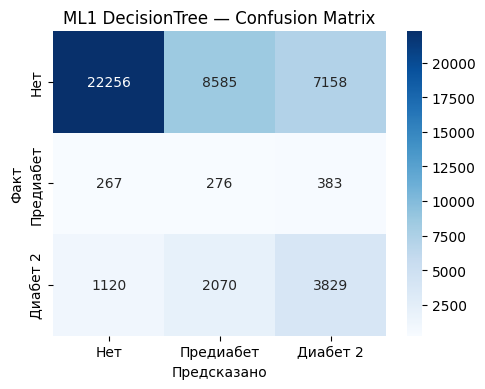

               precision    recall  f1-score   support

  Нет диабета       0.94      0.59      0.72     37999
    Предиабет       0.03      0.30      0.05       926
Диабет 2 типа       0.34      0.55      0.42      7019

     accuracy                           0.57     45944
    macro avg       0.43      0.48      0.40     45944
 weighted avg       0.83      0.57      0.66     45944

  📊 ML1 DecisionTree — K-fold (mean ± std):
     accuracy              : 0.5599 ± 0.0086
     f1_macro              : 0.3917 ± 0.0035
     precision_macro       : 0.4341 ± 0.0019
     recall_macro          : 0.4870 ± 0.0069


In [7]:
model_dt, res_dt = train_or_load(
    key          = "ML1_DecisionTree",
    model_factory= lambda: make_pipeline(DecisionTreeClassifier(
        criterion="gini", max_depth=10, min_samples_leaf=1,
        class_weight="balanced", random_state=42
    )),
    X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test,
    X_full=X, y_full=y, cv=skf
)
results_summary["ML1 DecisionTree"] = res_dt

## 6. ML2 — GradientBoostingClassifier (бустинг)

**Тип:** Ансамблевая модель — бустинг  
**Описание:** Последовательно строит деревья, каждое исправляет ошибки предыдущего путём оптимизации функции потерь по градиенту.  
**Гиперпараметры:** подобраны в Lab4 с помощью RandomizedSearchCV, F1-macro = 0.4179

📂 ML2 GradientBoosting: загружаем готовую модель (393.5 KB)
  📊 ML2 GradientBoosting — Hold-out метрики:
     Accuracy    : 0.8361
     Precision   : 0.4733
     Recall      : 0.3900
     F1-macro    : 0.3998


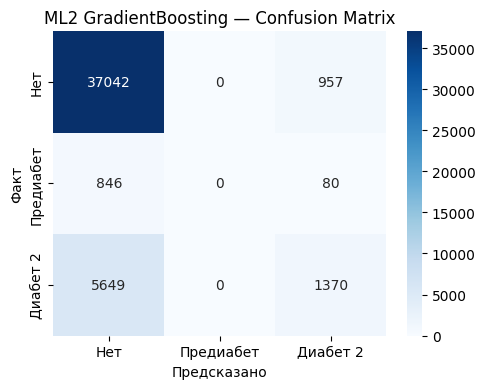

               precision    recall  f1-score   support

  Нет диабета       0.85      0.97      0.91     37999
    Предиабет       0.00      0.00      0.00       926
Диабет 2 типа       0.57      0.20      0.29      7019

     accuracy                           0.84     45944
    macro avg       0.47      0.39      0.40     45944
 weighted avg       0.79      0.84      0.80     45944

  📊 ML2 GradientBoosting — K-fold (mean ± std):
     accuracy              : 0.8352 ± 0.0014
     f1_macro              : 0.3979 ± 0.0024
     precision_macro       : 0.4699 ± 0.0051
     recall_macro          : 0.3887 ± 0.0017


In [8]:
model_gb, res_gb = train_or_load(
    key          = "ML2_GradientBoosting",
    model_factory= lambda: make_pipeline(GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3,
        subsample=1.0, random_state=42
    )),
    X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test,
    X_full=X, y_full=y, cv=skf
)
results_summary["ML2 GradientBoosting"] = res_gb

## 7. ML3 — CatBoostClassifier (продвинутый градиентный бустинг)

**Тип:** Продвинутый градиентный бустинг (Яндекс)  
**Описание:** Использует упорядоченный бустинг и симметричные деревья. Нативно поддерживает категориальные признаки.  
**Гиперпараметры:** подобраны в Lab4 с помощью GridSearchCV, F1-macro = 0.4222

📂 ML3 CatBoost: загружаем готовую модель (425.3 KB)
  📊 ML3 CatBoost — Hold-out метрики:
     Accuracy    : 0.8364
     Precision   : 0.4742
     Recall      : 0.3904
     F1-macro    : 0.4003


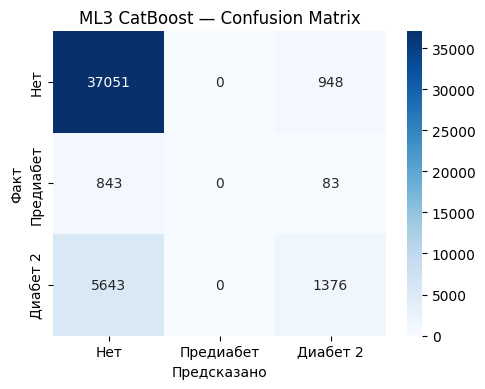

               precision    recall  f1-score   support

  Нет диабета       0.85      0.98      0.91     37999
    Предиабет       0.00      0.00      0.00       926
Диабет 2 типа       0.57      0.20      0.29      7019

     accuracy                           0.84     45944
    macro avg       0.47      0.39      0.40     45944
 weighted avg       0.79      0.84      0.80     45944



ValueError: not enough values to unpack (expected at least 1, got 0)

ValueError: not enough values to unpack (expected at least 1, got 0)

  📊 ML3 CatBoost — K-fold (mean ± std):
     accuracy              : 0.8356 ± 0.0011
     f1_macro              : 0.3986 ± 0.0023
     precision_macro       : 0.4713 ± 0.0043
     recall_macro          : 0.3892 ± 0.0016


In [9]:
from catboost import CatBoostClassifier

model_cb, res_cb = train_or_load(
    key          = "ML3_CatBoost",
    model_factory= lambda: make_pipeline(CatBoostClassifier(
        iterations=200, depth=6, learning_rate=0.1,
        verbose=0, random_state=42
    )),
    X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test,
    X_full=X, y_full=y, cv=skf
)
results_summary["ML3 CatBoost"] = res_cb

## 8. ML4 — BaggingClassifier (бэггинг)

**Тип:** Ансамблевая модель — бэггинг  
**Описание:** Обучает несколько деревьев на случайных bootstrap-подвыборках. Итоговое предсказание — большинство голосов.  
**Гиперпараметры:** подобраны в Lab4 с помощью GridSearchCV, F1-macro = 0.4019

📂 ML4 Bagging: загружаем готовую модель (233355.3 KB)
  📊 ML4 Bagging — Hold-out метрики:
     Accuracy    : 0.8154
     Precision   : 0.4234
     Recall      : 0.3881
     F1-macro    : 0.3945


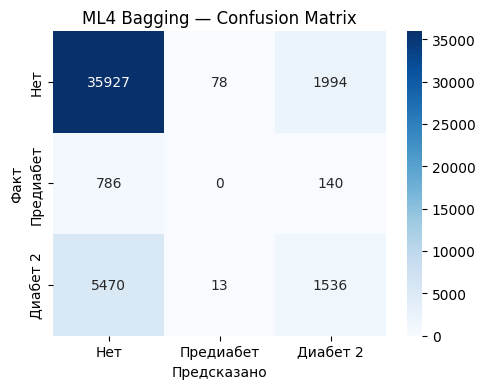

               precision    recall  f1-score   support

  Нет диабета       0.85      0.95      0.90     37999
    Предиабет       0.00      0.00      0.00       926
Диабет 2 типа       0.42      0.22      0.29      7019

     accuracy                           0.82     45944
    macro avg       0.42      0.39      0.39     45944
 weighted avg       0.77      0.82      0.79     45944

  📊 ML4 Bagging — K-fold (mean ± std):
     accuracy              : 0.8155 ± 0.0019
     f1_macro              : 0.3976 ± 0.0029
     precision_macro       : 0.4272 ± 0.0050
     recall_macro          : 0.3907 ± 0.0024


In [10]:
model_bag, res_bag = train_or_load(
    key          = "ML4_Bagging",
    model_factory= lambda: make_pipeline(BaggingClassifier(
        n_estimators=50, max_samples=1.0, max_features=1.0,
        bootstrap=True, random_state=42, n_jobs=2
    )),
    X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test,
    X_full=X, y_full=y, cv=skf
)
results_summary["ML4 Bagging"] = res_bag

## 9. ML5 — StackingClassifier (стэкинг)

**Тип:** Ансамблевая модель — стэкинг  
**Описание:** Базовые модели (DT + kNN + LR) генерируют предсказания, которые передаются в метаклассификатор LogisticRegression.  
**Гиперпараметры:** из Lab4, F1-macro = 0.4118

📂 ML5 Stacking: загружаем готовую модель (31597.7 KB)
  📊 ML5 Stacking — Hold-out метрики:
     Accuracy    : 0.8334
     Precision   : 0.4625
     Recall      : 0.3952
     F1-macro    : 0.4055


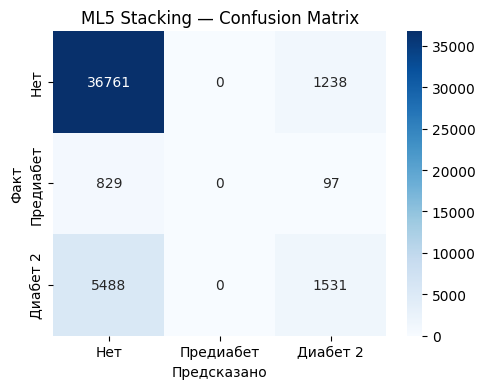

               precision    recall  f1-score   support

  Нет диабета       0.85      0.97      0.91     37999
    Предиабет       0.00      0.00      0.00       926
Диабет 2 типа       0.53      0.22      0.31      7019

     accuracy                           0.83     45944
    macro avg       0.46      0.40      0.41     45944
 weighted avg       0.79      0.83      0.80     45944

  📊 ML5 Stacking — K-fold (mean ± std):
     accuracy              : 0.8331 ± 0.0014
     f1_macro              : 0.4043 ± 0.0029
     precision_macro       : 0.4608 ± 0.0043
     recall_macro          : 0.3942 ± 0.0022


In [14]:
model_stack, res_stack = train_or_load(
    key          = "ML5_Stacking",
    model_factory= lambda: make_pipeline(
        StackingClassifier(
            estimators=[
                ("dt",  DecisionTreeClassifier(max_depth=5, random_state=42)),
                ("knn", KNeighborsClassifier(n_neighbors=7)),
                ("lr",  LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)),
            ],
            final_estimator=LogisticRegression(max_iter=5000, random_state=42),
            cv=3, n_jobs=2
        )
    ),
    X_tr=X_train, y_tr=y_train, X_ts=X_test, y_ts=y_test,
    X_full=X, y_full=y, cv=skf
)
results_summary["ML5 Stacking"] = res_stack

## 10. ML6 — MLPClassifier (нейронная сеть)

**Тип:** Глубокая полносвязная нейронная сеть  
**Описание:** MLP с гиперпараметрами из Lab7 (Sklearn+Hyperopt, F1-weighted=0.7920).  
**Ключевые условия Lab7, которые воспроизводятся здесь:**
1. Стратифицированный ресэмплинг обучающей выборки до **15 000 записей** (балансировка классов)
2. Отбор значимых признаков через **SelectKBest(f_classif)**
3. Архитектура и гиперпараметры: `hidden_layer_sizes=(128, 64)`, `activation=relu`, `solver=adam`

> ⚠️ Pipeline для инференса включает: `StandardScaler → SelectKBest → MLPClassifier`  
> Это важно — `app.py` должен подавать **все 21 признак**, Pipeline сам сделает отбор.

In [15]:
RGR_NN_PATH = MODEL_PATHS["ML6_NeuralNetwork"]

if os.path.exists(RGR_NN_PATH):
    print(f"📂 ML6_NeuralNetwork: загружаем готовую модель ({os.path.getsize(RGR_NN_PATH)/1024:.1f} KB)")
    model_nn = joblib.load(RGR_NN_PATH)
else:
    print("🔨 ML6_NeuralNetwork: обучаем по условиям Lab7...")

    MAX_SAMPLES = 15000
    X_tr_res, y_tr_res = resample(
        X_train, y_train,
        n_samples=MAX_SAMPLES,
        random_state=42,
        stratify=y_train
    )
    print(f"  После ресэмплинга: {X_tr_res.shape[0]} записей")
    print(f"  Распределение классов: {dict(pd.Series(y_tr_res).value_counts().sort_index())}")

    scaler_nn = StandardScaler()
    X_tr_scaled = scaler_nn.fit_transform(X_tr_res)
    X_ts_scaled = scaler_nn.transform(X_test)

    selector_nn = SelectKBest(f_classif, k="all").fit(X_tr_scaled, y_tr_res)
    sig_mask = selector_nn.pvalues_ < 0.05
    k_best = max(sig_mask.sum(), 5)
    selector_nn = SelectKBest(f_classif, k=k_best).fit(X_tr_scaled, y_tr_res)
    X_tr_sel = selector_nn.transform(X_tr_scaled)
    X_ts_sel = selector_nn.transform(X_ts_scaled)
    print(f"  Отобрано признаков: {k_best} из {X_train.shape[1]}")

    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=42,
        verbose=True
    )
    mlp.fit(X_tr_sel, y_tr_res)

    model_nn = Pipeline([
        ("scaler",   scaler_nn),
        ("selector", selector_nn),
        ("model",    mlp),
    ])
    joblib.dump(model_nn, RGR_NN_PATH)
    print(f"💾 Сохранена: {RGR_NN_PATH}")


📂 ML6_NeuralNetwork: загружаем готовую модель (268.8 KB)


  📊 ML6 NeuralNetwork — Hold-out метрики:
     Accuracy    : 0.8250
     Precision   : 0.4398
     Recall      : 0.3936
     F1-macro    : 0.4017


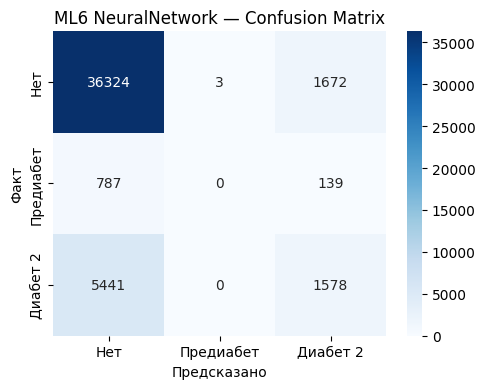

               precision    recall  f1-score   support

  Нет диабета       0.85      0.96      0.90     37999
    Предиабет       0.00      0.00      0.00       926
Диабет 2 типа       0.47      0.22      0.30      7019

     accuracy                           0.82     45944
    macro avg       0.44      0.39      0.40     45944
 weighted avg       0.78      0.82      0.79     45944



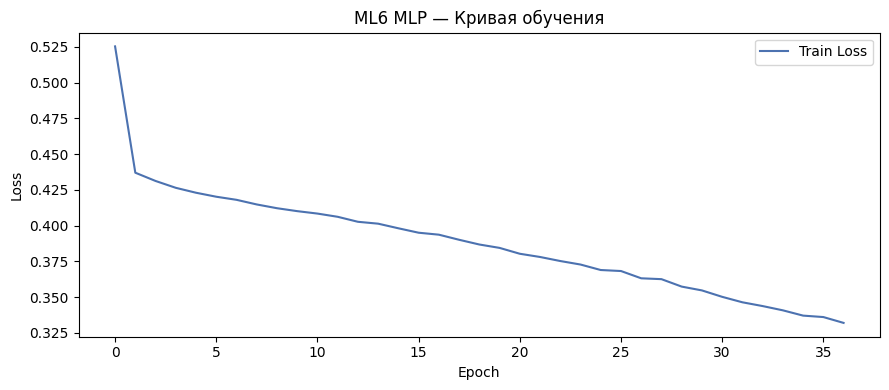

In [16]:
y_pred_nn = np.array(model_nn.predict(X_test)).flatten().astype(int)
res_nn = print_metrics("ML6 NeuralNetwork", y_test, y_pred_nn)
plot_confusion(y_test, y_pred_nn, "ML6 NeuralNetwork — Confusion Matrix")
print(classification_report(y_test, y_pred_nn,
      target_names=["Нет диабета", "Предиабет", "Диабет 2 типа"]))

try:
    mlp_step = model_nn["model"]
    if hasattr(mlp_step, "loss_curve_"):
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(mlp_step.loss_curve_, label="Train Loss", color="#4c72b0")
        ax.set(xlabel="Epoch", ylabel="Loss", title="ML6 MLP — Кривая обучения")
        ax.legend()
        plt.tight_layout()
        plt.show()
except Exception:
    pass

results_summary["ML6 NeuralNetwork"] = res_nn


## 11. Итоговая сравнительная таблица

ИТОГОВЫЕ МЕТРИКИ (Hold-out)


,Accuracy,Precision,Recall,F1-macro
Модель,,,,
ML1 DecisionTree,0.5738,0.4344,0.4764,0.3950
ML2 GradientBoosting,0.8361,0.4733,0.3900,0.3998
ML3 CatBoost,0.8364,0.4742,0.3904,0.4003
ML4 Bagging,0.8154,0.4234,0.3881,0.3945
ML5 Stacking,0.8334,0.4625,0.3952,0.4055
ML6 NeuralNetwork,0.8250,0.4398,0.3936,0.4017


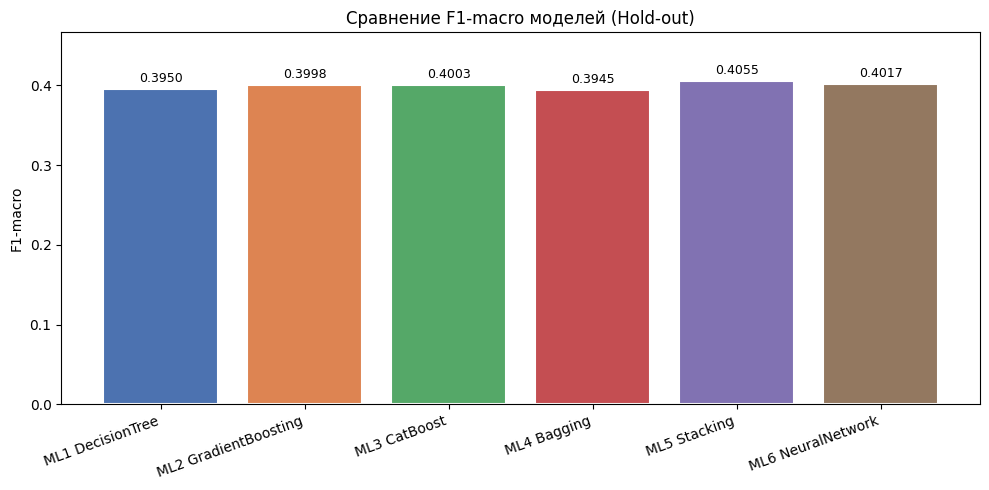

In [17]:
df_res = pd.DataFrame(results_summary).T.round(4)
df_res.index.name = "Модель"
print("=" * 60)
print("ИТОГОВЫЕ МЕТРИКИ (Hold-out)")
print("=" * 60)
display(df_res)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b2", "#937860"]
bars = ax.bar(df_res.index, df_res["F1-macro"], color=colors, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, df_res["F1-macro"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax.set(ylabel="F1-macro", title="Сравнение F1-macro моделей (Hold-out)")
ax.set_ylim(0, max(df_res["F1-macro"]) * 1.15)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 12. Финальная проверка сохранённых файлов

Убедимся, что все модели на месте и корректно загружаются.

In [18]:
print("Статус файлов моделей:")
print("-" * 60)
all_ok = True
for name, path in MODEL_PATHS.items():
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1024:.1f} KB" if exists else "нет файла"
    icon   = "✅" if exists else "❌"
    print(f"  {icon} {name:<28} {size}")
    if not exists:
        all_ok = False
print("-" * 60)
print("✅ Все модели готовы!" if all_ok else "❌ Некоторые файлы отсутствуют")

Статус файлов моделей:
------------------------------------------------------------
  ✅ ML1_DecisionTree             162.8 KB
  ✅ ML2_GradientBoosting         393.5 KB
  ✅ ML3_CatBoost                 425.3 KB
  ✅ ML4_Bagging                  233355.3 KB
  ✅ ML5_Stacking                 31597.7 KB
  ✅ ML6_NeuralNetwork            268.8 KB
------------------------------------------------------------
✅ Все модели готовы!


In [19]:
sample   = X_test.sample(3, random_state=7)
true_lbl = y_test.loc[sample.index]
lbl_map  = {0: "Нет диабета", 1: "Предиабет", 2: "Диабет 2 типа"}

print("Тестовые предсказания на 3 случайных пациентах:")
print("-" * 60)
for name, path in MODEL_PATHS.items():
    if not os.path.exists(path):
        continue
    m = joblib.load(path)
    preds = np.array(m.predict(sample)).flatten().astype(int)
    row = "  ".join([
        f"{lbl_map[p]} ({"✅" if p == t else "❌"} факт: {lbl_map[t]})"
        for p, t in zip(preds, true_lbl.values)
    ])
    print(f"  {name:<28} {row}")

Тестовые предсказания на 3 случайных пациентах:
------------------------------------------------------------
  ML1_DecisionTree             Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)
  ML2_GradientBoosting         Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)
  ML3_CatBoost                 Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)
  ML4_Bagging                  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)
  ML5_Stacking                 Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)
  ML6_NeuralNetwork            Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)  Нет диабета (✅ факт: Нет диабета)


In [20]:
app_content = f"""
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

st.set_page_config(
    page_title="ML Дашборд — Diabetes Health Indicators",
    page_icon="🩺",
    layout="wide"
)

st.markdown(\"\"\"
<style>
    .main-header {{font-size: 2.2rem; font-weight: 700; color: #1f4e79; margin-bottom: 0.2rem;}}
    .sub-header  {{font-size: 1.1rem; color: #555; margin-bottom: 1.5rem;}}
    .metric-card {{
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        padding: 1rem 1.5rem; border-radius: 12px; color: white !important;
        text-align: center; margin-bottom: 0.5rem;
    }}
    .metric-card * {{ color: white !important; }}
    .info-box {{
        background: #f0f4ff; border-left: 4px solid #4c72b0;
        padding: 0.8rem 1.2rem; border-radius: 0 8px 8px 0; margin: 0.5rem 0;
        color: #1a1a1a !important;
    }}
    .info-box * {{ color: #1a1a1a !important; }}
    .info-box b, .info-box strong {{ color: #1f4e79 !important; }}
    .info-box code {{ color: #c0392b !important; background: #e8eaf6; padding: 1px 4px; border-radius: 3px; }}
    .result-positive {{
        background: #d4edda; border-left: 5px solid #28a745;
        padding: 1rem; border-radius: 0 8px 8px 0; font-weight: bold;
        color: #155724 !important;
    }}
    .result-positive * {{ color: #155724 !important; }}
    .result-negative {{
        background: #fff3cd; border-left: 5px solid #ffc107;
        padding: 1rem; border-radius: 0 8px 8px 0; font-weight: bold;
        color: #856404 !important;
    }}
    .result-negative * {{ color: #856404 !important; }}
    .result-danger {{
        background: #f8d7da; border-left: 5px solid #dc3545;
        padding: 1rem; border-radius: 0 8px 8px 0; font-weight: bold;
        color: #721c24 !important;
    }}
    .result-danger * {{ color: #721c24 !important; }}
    [data-testid="stSidebar"] {{background: linear-gradient(180deg, #1f4e79 0%, #2e6da4 100%);}}
    [data-testid="stSidebar"] * {{color: white !important;}}
</style>
\"\"\", unsafe_allow_html=True)

FEATURE_NAMES = [
    'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
    'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income'
]

FEATURE_DESCRIPTIONS = {{
    'HighBP':               ('Высокое артериальное давление', 'бинарный (0 — нет, 1 — да)'),
    'HighChol':             ('Высокий холестерин', 'бинарный (0 — нет, 1 — да)'),
    'CholCheck':            ('Проверка холестерина за последние 5 лет', 'бинарный (0 — нет, 1 — да)'),
    'BMI':                  ('Индекс массы тела', 'числовой'),
    'Smoker':               ('Курение (≥100 сигарет за жизнь)', 'бинарный (0 — нет, 1 — да)'),
    'Stroke':               ('Инсульт в анамнезе', 'бинарный (0 — нет, 1 — да)'),
    'HeartDiseaseorAttack': ('Ишемическая болезнь / инфаркт', 'бинарный (0 — нет, 1 — да)'),
    'PhysActivity':         ('Физическая активность за последние 30 дней', 'бинарный (0 — нет, 1 — да)'),
    'Fruits':               ('Употребление фруктов ≥1 раза в день', 'бинарный (0 — нет, 1 — да)'),
    'Veggies':              ('Употребление овощей ≥1 раза в день', 'бинарный (0 — нет, 1 — да)'),
    'HvyAlcoholConsump':    ('Злоупотребление алкоголем', 'бинарный (0 — нет, 1 — да)'),
    'AnyHealthcare':        ('Наличие медицинской страховки', 'бинарный (0 — нет, 1 — да)'),
    'NoDocbcCost':          ('Не мог позволить врача из-за стоимости', 'бинарный (0 — нет, 1 — да)'),
    'GenHlth':              ('Общее состояние здоровья', 'порядковый (1 — отличное … 5 — плохое)'),
    'MentHlth':             ('Дней с плохим психическим здоровьем (за 30 дней)', 'числовой (0–30)'),
    'PhysHlth':             ('Дней с плохим физическим здоровьем (за 30 дней)', 'числовой (0–30)'),
    'DiffWalk':             ('Трудности при ходьбе / подъёме по лестнице', 'бинарный (0 — нет, 1 — да)'),
    'Sex':                  ('Пол', '0 — женский, 1 — мужской'),
    'Age':                  ('Возрастная группа', 'порядковый (1=18–24, …, 13=80+)'),
    'Education':            ('Уровень образования', 'порядковый (1–6)'),
    'Income':               ('Уровень дохода', 'порядковый (1–8)'),
}}

MODEL_INFO = {{
    'DecisionTree':    {{'path': 'models/dt_classifier_model.pkl',   'f1': {res_dt['F1-macro']:.4f}, 'label': 'Дерево решений (ML1)'}},
    'GradientBoosting':{{'path': 'models/gb_classifier_model.pkl',   'f1': {res_gb['F1-macro']:.4f}, 'label': 'Gradient Boosting (ML2)'}},
    'CatBoost':        {{'path': 'models/cb_classifier_model.pkl',   'f1': {res_cb['F1-macro']:.4f}, 'label': 'CatBoost (ML3)'}},
    'Bagging':         {{'path': 'models/bag_classifier_model.pkl',  'f1': {res_bag['F1-macro']:.4f}, 'label': 'Bagging (ML4)'}},
    'Stacking':        {{'path': 'models/stack_classifier_model.pkl','f1': {res_stack['F1-macro']:.4f}, 'label': 'Stacking (ML5)'}},
    'NeuralNetwork':   {{'path': 'models/nn_classifier_model.pkl',   'f1': {res_nn['F1-macro']:.4f}, 'label': 'Нейронная сеть MLP (ML6)'}},
}}

CLASS_LABELS = {{0: 'Нет диабета', 1: 'Предиабет', 2: 'Диабет 2 типа'}}
CLASS_COLORS = {{0: 'result-positive', 1: 'result-negative', 2: 'result-danger'}}
CLASS_EMOJI  = {{0: '✅', 1: '⚠️', 2: '🔴'}}

AGE_GROUPS = {{
    1: '18–24', 2: '25–29', 3: '30–34', 4: '35–39', 5: '40–44',
    6: '45–49', 7: '50–54', 8: '55–59', 9: '60–64', 10: '65–69',
    11: '70–74', 12: '75–79', 13: '80+',
}}

@st.cache_resource
def load_model(path):
    if not os.path.exists(path):
        return None
    obj = joblib.load(path)
    return obj


def predict_with_model(model_key, model_obj, X):
    if isinstance(model_obj, dict) and 'scaler' in model_obj:
        X_sc = model_obj['scaler'].transform(X)
        preds = model_obj['model'].predict(X_sc)
    else:
        preds = model_obj.predict(X)

    preds = np.array(preds)
    if preds.ndim > 1:
        preds = preds.flatten()
    return preds.astype(int)

@st.cache_data
def load_dataset():
    candidates = [
        'filtered_diabetes_health_indicators.csv',
        '/datasets/filtered_diabetes_health_indicators.csv',
        'data/filtered_diabetes_health_indicators.csv',
    ]
    for p in candidates:
        if os.path.exists(p):
            return pd.read_csv(p)
    return None

def page_developer():
    st.markdown('<div class="main-header">👨‍💻 Информация о разработчике</div>', unsafe_allow_html=True)

    col1, col2 = st.columns([1, 2])
    with col1:
        photo_found = False
        for photo_path in ['photo.jpg', 'Photo.jpg', 'photo.png', 'Photo.png']:
            if os.path.exists(photo_path):
                st.image(photo_path, caption='Фото разработчика', width=280)
                photo_found = True
                break
        if not photo_found:
            st.markdown(\"\"\"
            <div style="width:280px;height:320px;background:linear-gradient(135deg,#667eea,#764ba2);
                        border-radius:12px;display:flex;align-items:center;justify-content:center;
                        font-size:6rem;">👤</div>
            \"\"\", unsafe_allow_html=True)

    with col2:
        st.markdown("### 📋 Личные данные")
        st.markdown(\"\"\"
        <div style="background:#f0f4ff; border-left:4px solid #4c72b0;
                    padding:0.8rem 1.2rem; border-radius:0 8px 8px 0; margin:0.5rem 0;
                    color:#1a1a1a !important;">
        <span style="color:#1a1a1a;"><b style="color:#1f4e79;">ФИО:</b> Рау Алексей Евгеньевич<br>
        <b style="color:#1f4e79;">Группа:</b> ФИТ-231<br>
        <b style="color:#1f4e79;">Дисциплина:</b> Машинное обучение и большие данные</span>
        </div>
        \"\"\", unsafe_allow_html=True)

        st.markdown("### 🎯 Тема РГР")
        st.markdown(\"\"\"
        <div style="background:#f0f4ff; border-left:4px solid #4c72b0;
                    padding:0.8rem 1.2rem; border-radius:0 8px 8px 0; margin:0.5rem 0;">
        <span style="color:#1a1a1a;">
        <b style="color:#1f4e79;">Разработка Web-приложения (дашборда) для инференса (вывода) моделей ML
        и анализа данных</b><br><br>
        Датасет: <i>Diabetes Health Indicators</i> — прогнозирование статуса диабета
        у пациентов (CDC BRFSS 2015)
        </span>
        </div>
        \"\"\", unsafe_allow_html=True)

        st.markdown("### 🛠️ Стек технологий")
        cols = st.columns(3)
        tech = [
            ('🐍', 'Python 3.11'),
            ('🤖', 'Scikit-learn'),
            ('🔥', 'TensorFlow'),
            ('🚀', 'Streamlit'),
            ('🐼', 'Pandas / NumPy'),
            ('📊', 'Matplotlib / Seaborn'),
        ]
        for i, (emoji, name) in enumerate(tech):
            cols[i % 3].markdown(
                f'<div style="background:linear-gradient(135deg,#667eea,#764ba2);'
                f'padding:1rem 1.5rem;border-radius:12px;text-align:center;margin-bottom:0.5rem;">'
                f'<span style="color:white;font-size:1.4rem;">{{emoji}}</span><br>'
                f'<b style="color:white;">{{name}}</b></div>',
                unsafe_allow_html=True)

    st.divider()
    st.markdown("### 📚 Используемые модели ML")
    cols = st.columns(3)
    for i, (key, info) in enumerate(MODEL_INFO.items()):
        cols[i % 3].markdown(
            f\"\"\"<div style="background:#f0f4ff; border-left:4px solid #4c72b0;
                padding:0.8rem 1.2rem; border-radius:0 8px 8px 0; margin:0.5rem 0;">
            <span style="color:#1a1a1a;">
            <b style="color:#1f4e79;">{{info['label']}}</b><br>
            F1-macro (hold-out): <code style="color:#c0392b;background:#e8eaf6;
            padding:1px 5px;border-radius:3px;">{{info['f1']:.4f}}</code>
            </span></div>\"\"\",
            unsafe_allow_html=True)

def page_dataset():
    st.markdown('<div class="main-header">📊 Информация о датасете</div>', unsafe_allow_html=True)

    st.markdown(\"\"\"
    <div style="background:#f0f4ff; border-left:4px solid #4c72b0;
                padding:0.8rem 1.2rem; border-radius:0 8px 8px 0; margin:0.5rem 0;">
    <span style="color:#1a1a1a;">
    <b style="color:#1f4e79;">Название:</b> Diabetes Health Indicators (CDC BRFSS 2015)<br>
    <b style="color:#1f4e79;">Источник:</b> Behavioral Risk Factor Surveillance System (CDC, США)<br>
    <b style="color:#1f4e79;">Размер:</b> 229 718 записей, 22 признака<br>
    <b style="color:#1f4e79;">Задача:</b> Мультиклассовая классификация (3 класса)
    </span>
    </div>
    \"\"\", unsafe_allow_html=True)

    st.markdown("### 🎯 Целевая переменная")
    col1, col2, col3 = st.columns(3)
    for col, (cls, label, cnt) in zip([col1, col2, col3], [
        (0, 'Нет диабета',  '189 994 (82.7%)'),
        (1, 'Предиабет',    '4 629 (2.0%)'),
        (2, 'Диабет 2 типа','35 095 (15.3%)'),
    ]):
        col.markdown(f\"\"\"
        <div style="background:linear-gradient(135deg,#667eea,#764ba2);
                    padding:1rem 1.5rem; border-radius:12px; text-align:center; margin-bottom:0.5rem;">
        <div style="font-size:1.8rem; color:white;">{{CLASS_EMOJI[cls]}}</div>
        <b style="color:white;">Класс {{cls}}</b><br>
        <span style="color:white;">{{label}}</span><br>
        <small style="color:rgba(255,255,255,0.85);">{{cnt}}</small>
        </div>\"\"\", unsafe_allow_html=True)

    st.markdown("### 📝 Описание признаков")
    rows = []
    for feat, (desc, dtype) in FEATURE_DESCRIPTIONS.items():
        rows.append({{'Признак': feat, 'Описание': desc, 'Тип / шкала': dtype}})
    st.dataframe(pd.DataFrame(rows), use_container_width=True, hide_index=True)

    st.markdown("### 🔧 Предобработка данных")
    st.markdown(\"\"\"
    <div style="background:#f0f4ff; border-left:4px solid #4c72b0;
                padding:0.8rem 1.2rem; border-radius:0 8px 8px 0; margin:0.5rem 0;">
    <ol style="color:#1a1a1a; margin:0; padding-left:1.2rem;">
    <li style="color:#1a1a1a;"><b style="color:#1f4e79;">Загрузка данных.</b> Датасет загружался из CSV-файла (229 718 строк × 22 столбца).</li>
    <li style="color:#1a1a1a;"><b style="color:#1f4e79;">Обработка пропусков.</b> Пропущенные значения отсутствуют — датасет уже очищен.</li>
    <li style="color:#1a1a1a;"><b style="color:#1f4e79;">Выделение признаков и целевой переменной.</b> X — 21 признак, y — Diabetes_012.</li>
    <li style="color:#1a1a1a;"><b style="color:#1f4e79;">Разбиение.</b> Hold-out 80/20 со стратификацией (stratify=y, random_state=42).</li>
    <li style="color:#1a1a1a;"><b style="color:#1f4e79;">Масштабирование.</b> StandardScaler применялся к обучающей выборке (fit_transform), к тестовой — только transform.</li>
    <li style="color:#1a1a1a;"><b style="color:#1f4e79;">Балансировка классов.</b> SMOTE применялся к обучающей выборке для устранения дисбаланса классов.</li>
    <li style="color:#1a1a1a;"><b style="color:#1f4e79;">K-fold валидация.</b> StratifiedKFold(n_splits=5) для надёжной оценки обобщающей способности.</li>
    </ol>
    </div>\"\"\", unsafe_allow_html=True)

    st.markdown("### 🔍 EDA (разведочный анализ данных)")
    df = load_dataset()
    if df is not None:
        col1, col2, col3, col4 = st.columns(4)
        col1.metric("Строк",     f"{{df.shape[0]:,}}")
        col2.metric("Признаков", df.shape[1])
        col3.metric("Пропусков", int(df.isnull().sum().sum()))
        col4.metric("Дубликатов", int(df.duplicated().sum()))

        with st.expander("📋 Первые 10 строк датасета"):
            st.dataframe(df.head(10), use_container_width=True)
        with st.expander("📈 Статистика по числовым признакам"):
            st.dataframe(df.describe().round(2), use_container_width=True)
    else:
        st.info("ℹ️ Добавьте файл `filtered_diabetes_health_indicators.csv` в папку с приложением для отображения данных.")

def page_visualizations():
    st.markdown('<div class="main-header">📈 Визуализации данных</div>', unsafe_allow_html=True)

    df = load_dataset()
    if df is None:
        st.warning("⚠️ Добавьте файл `filtered_diabetes_health_indicators.csv` для отображения визуализаций.")
        _demo_visualizations()
        return

    _real_visualizations(df)


def _demo_visualizations():
    st.info("📊 Отображаются демонстрационные графики на синтетических данных")
    rng = np.random.default_rng(42)
    n = 1000
    df_demo = pd.DataFrame({{
        'BMI':     rng.normal(28, 6, n).clip(12, 70),
        'Age':     rng.integers(1, 14, n),
        'GenHlth': rng.integers(1, 6, n),
        'MentHlth':rng.integers(0, 31, n),
        'PhysHlth':rng.integers(0, 31, n),
        'Diabetes_012': rng.choice([0, 1, 2], n, p=[0.83, 0.02, 0.15]),
    }})
    _real_visualizations(df_demo)


def _real_visualizations(df):
    target = 'Diabetes_012'
    num_cols = ['BMI', 'Age', 'GenHlth', 'MentHlth', 'PhysHlth']
    bin_cols = ['HighBP', 'HighChol', 'Smoker', 'Stroke',
                'HeartDiseaseorAttack', 'PhysActivity', 'DiffWalk']
    num_cols = [c for c in num_cols if c in df.columns]
    bin_cols = [c for c in bin_cols if c in df.columns]

    palette = {{0: '#55a868', 1: '#f4a623', 2: '#dd4b39'}}

    st.subheader("1️⃣ Распределение целевой переменной (Diabetes_012)")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    counts = df[target].value_counts().sort_index()
    labels = [CLASS_LABELS[i] for i in counts.index]
    axes[0].bar(labels, counts.values, color=[palette[i] for i in counts.index], edgecolor='white', linewidth=1.5)
    axes[0].set_title("Количество наблюдений по классам")
    axes[0].set_ylabel("Количество")
    for j, v in enumerate(counts.values):
        axes[0].text(j, v + 500, f'{{v:,}}', ha='center', fontsize=9)
    axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
                colors=[palette[i] for i in counts.index], startangle=140,
                wedgeprops={{'edgecolor': 'white', 'linewidth': 2}})
    axes[1].set_title("Доля классов")
    plt.tight_layout()
    st.pyplot(fig)
    plt.close()

    st.subheader("2️⃣ Распределения числовых признаков по классам (Box-plot)")
    if num_cols:
        fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))
        if len(num_cols) == 1:
            axes = [axes]
        for ax, col in zip(axes, num_cols):
            data_by_class = [df[df[target] == cls][col].dropna() for cls in [0, 1, 2] if cls in df[target].values]
            bp = ax.boxplot(data_by_class, patch_artist=True, notch=False,
                            medianprops={{'color': 'black', 'linewidth': 2}})
            for patch, cls in zip(bp['boxes'], [0, 1, 2]):
                patch.set_facecolor(palette.get(cls, 'gray'))
                patch.set_alpha(0.7)
            ax.set_title(col)
            ax.set_xticklabels(['Норма', 'Предиабет', 'Диабет'], rotation=20, fontsize=8)
            ax.set_ylabel(col)
        plt.suptitle("Box-plot числовых признаков по классам", fontsize=12, y=1.02)
        plt.tight_layout()
        st.pyplot(fig)
        plt.close()

    st.subheader("3️⃣ Тепловая карта корреляций")
    corr_cols = [c for c in FEATURE_NAMES if c in df.columns] + [target]
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(13, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, annot_kws={{'size': 7}},
                linewidths=0.5, square=True)
    ax.set_title("Матрица корреляций признаков (нижний треугольник)", fontsize=13, pad=15)
    plt.tight_layout()
    st.pyplot(fig)
    plt.close()

    st.subheader("4️⃣ Доля заболевших диабетом по бинарным признакам")
    if bin_cols:
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.flatten()
        for i, col in enumerate(bin_cols[:8]):
            ct = df.groupby([col, target]).size().unstack(fill_value=0)
            ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
            ct_pct.plot(kind='bar', ax=axes[i], stacked=True,
                        color=[palette.get(c, 'gray') for c in ct_pct.columns],
                        legend=(i == 0), rot=0)
            axes[i].set_title(col, fontsize=10)
            axes[i].set_ylabel("% наблюдений")
            axes[i].set_xlabel("")
        for j in range(len(bin_cols), 8):
            axes[j].set_visible(False)
        handles = [plt.Rectangle((0,0),1,1, color=palette[c]) for c in [0,1,2]]
        fig.legend(handles, [CLASS_LABELS[c] for c in [0,1,2]],
                   loc='lower right', frameon=True)
        plt.suptitle("Стековые столбчатые диаграммы: доля классов по бинарным признакам",
                     fontsize=12, y=1.01)
        plt.tight_layout()
        st.pyplot(fig)
        plt.close()

    if 'BMI' in df.columns and 'Age' in df.columns:
        st.subheader("5️⃣ BMI vs Возраст — scatter plot по классам")
        sample = df.sample(min(5000, len(df)), random_state=42)
        fig, ax = plt.subplots(figsize=(10, 5))
        for cls in [0, 1, 2]:
            subset = sample[sample[target] == cls]
            ax.scatter(subset['Age'], subset['BMI'],
                       alpha=0.35, s=15, c=palette[cls], label=CLASS_LABELS[cls])
        ax.set_xlabel("Возрастная группа")
        ax.set_ylabel("BMI")
        ax.set_title("Зависимость BMI от возраста (выборка 5 000 записей)")
        ax.legend()
        ax.set_xticks(range(1, 14))
        ax.set_xticklabels([AGE_GROUPS[i] for i in range(1, 14)], rotation=45, fontsize=7)
        plt.tight_layout()
        st.pyplot(fig)
        plt.close()

def page_prediction():
    st.markdown('<div class="main-header">🤖 Предсказание моделей ML</div>', unsafe_allow_html=True)

    model_keys = list(MODEL_INFO.keys())
    selected = st.multiselect(
        "Выберите модели для предсказания:",
        model_keys,
        default=model_keys,
        format_func=lambda k: MODEL_INFO[k]['label']
    )

    tab1, tab2 = st.tabs(["📂 Загрузка CSV", "✍️ Ручной ввод"])

    with tab1:
        st.markdown(\"\"\"
        <div style="background:#f0f4ff; border-left:4px solid #4c72b0;
                    padding:0.8rem 1.2rem; border-radius:0 8px 8px 0; margin:0.5rem 0;">
        <span style="color:#1a1a1a;">
        Загрузите CSV-файл, содержащий признаки пациентов. Файл должен содержать столбцы:<br>
        <code style="color:#c0392b; background:#e8eaf6; padding:2px 5px; border-radius:3px;
                     font-size:0.85rem;">HighBP, HighChol, CholCheck, BMI, Smoker, Stroke,
        HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare,
        NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income</code>
        </span>
        </div>
        \"\"\", unsafe_allow_html=True)
        uploaded = st.file_uploader("Загрузите CSV-файл с данными пациентов:", type=['csv'])

        if uploaded:
            try:
                df_in = pd.read_csv(uploaded)
                st.write("**Превью загруженных данных:**")
                st.dataframe(df_in.head(), use_container_width=True)

                missing_cols = [c for c in FEATURE_NAMES if c not in df_in.columns]
                if missing_cols:
                    st.error(f"❌ В файле отсутствуют столбцы: {{missing_cols}}")
                else:
                    X_input = df_in[FEATURE_NAMES].copy()
                    if not ((X_input['BMI'] >= 10) & (X_input['BMI'] <= 100)).all():
                        st.warning("⚠️ Некоторые значения BMI выходят за ожидаемый диапазон (10–100)")
                    _run_predictions(X_input, selected)
            except Exception as e:
                st.error(f"Ошибка чтения файла: {{e}}")

    with tab2:
        st.markdown("#### Введите данные пациента")

        col1, col2, col3 = st.columns(3)

        with col1:
            st.markdown("**🩺 Состояние здоровья**")
            high_bp   = st.selectbox("Высокое артериальное давление", [0, 1],
                                      format_func=lambda x: "Нет" if x == 0 else "Да",
                                      key='bp')
            high_chol = st.selectbox("Высокий холестерин", [0, 1],
                                      format_func=lambda x: "Нет" if x == 0 else "Да",
                                      key='chol')
            chol_check= st.selectbox("Проверка холестерина за 5 лет", [0, 1],
                                      format_func=lambda x: "Нет" if x == 0 else "Да",
                                      key='ccheck')
            stroke    = st.selectbox("Инсульт в анамнезе", [0, 1],
                                      format_func=lambda x: "Нет" if x == 0 else "Да",
                                      key='stroke')
            heart_dis = st.selectbox("Ишемическая болезнь / инфаркт", [0, 1],
                                      format_func=lambda x: "Нет" if x == 0 else "Да",
                                      key='heart')
            diff_walk = st.selectbox("Трудности с ходьбой", [0, 1],
                                      format_func=lambda x: "Нет" if x == 0 else "Да",
                                      key='walk')
            gen_hlth  = st.slider("Общее состояние здоровья (1=отлично, 5=плохое)", 1, 5, 3, key='ghlth')

        with col2:
            st.markdown("**📏 Физические показатели**")
            bmi       = st.slider("ИМТ (BMI)", 10.0, 98.0, 26.0, 0.5, key='bmi')
            ment_hlth = st.slider("Дней с плохим психическим здоровьем (30 дней)", 0, 30, 0, key='mhlth')
            phys_hlth = st.slider("Дней с плохим физическим здоровьем (30 дней)", 0, 30, 0, key='phlth')
            sex       = st.selectbox("Пол", [0, 1],
                                      format_func=lambda x: "Женский" if x == 0 else "Мужской",
                                      key='sex')
            age       = st.select_slider("Возрастная группа", options=list(AGE_GROUPS.keys()),
                                          format_func=lambda x: AGE_GROUPS[x], key='age')

            st.markdown("**💊 Образ жизни**")
            smoker      = st.selectbox("Курение (≥100 сигарет)", [0, 1],
                                        format_func=lambda x: "Нет" if x == 0 else "Да", key='smoker')
            phys_act    = st.selectbox("Физическая активность (30 дней)", [0, 1],
                                        format_func=lambda x: "Нет" if x == 0 else "Да", key='phys')
            fruits      = st.selectbox("Фрукты ≥1 раза в день", [0, 1],
                                        format_func=lambda x: "Нет" if x == 0 else "Да", key='fruits')
            veggies     = st.selectbox("Овощи ≥1 раза в день", [0, 1],
                                        format_func=lambda x: "Нет" if x == 0 else "Да", key='veggies')
            hvy_alc     = st.selectbox("Злоупотребление алкоголем", [0, 1],
                                        format_func=lambda x: "Нет" if x == 0 else "Да", key='alc')

        with col3:
            st.markdown("**🏥 Социально-экономические факторы**")
            any_hc      = st.selectbox("Наличие медицинской страховки", [0, 1],
                                        format_func=lambda x: "Нет" if x == 0 else "Да", key='hc')
            no_doc      = st.selectbox("Не мог позволить врача (стоимость)", [0, 1],
                                        format_func=lambda x: "Нет" if x == 0 else "Да", key='nodoc')
            education   = st.slider("Уровень образования (1–6)", 1, 6, 4, key='edu')
            income      = st.slider("Уровень дохода (1–8)", 1, 8, 5, key='income')

            st.markdown("---")
            st.markdown("**ℹ️ Расшифровка ИМТ**")
            if bmi < 18.5:
                st.warning(f"BMI {{bmi:.1f}} — Недостаточный вес")
            elif bmi < 25:
                st.success(f"BMI {{bmi:.1f}} — Норма")
            elif bmi < 30:
                st.warning(f"BMI {{bmi:.1f}} — Избыточный вес")
            else:
                st.error(f"BMI {{bmi:.1f}} — Ожирение")

        predict_btn = st.button("🔮 Получить предсказание", type="primary", use_container_width=True)

        if predict_btn:
            X_manual = pd.DataFrame([{{
                'HighBP': high_bp, 'HighChol': high_chol, 'CholCheck': chol_check,
                'BMI': bmi, 'Smoker': smoker, 'Stroke': stroke,
                'HeartDiseaseorAttack': heart_dis, 'PhysActivity': phys_act,
                'Fruits': fruits, 'Veggies': veggies, 'HvyAlcoholConsump': hvy_alc,
                'AnyHealthcare': any_hc, 'NoDocbcCost': no_doc,
                'GenHlth': gen_hlth, 'MentHlth': ment_hlth, 'PhysHlth': phys_hlth,
                'DiffWalk': diff_walk, 'Sex': sex, 'Age': age,
                'Education': education, 'Income': income,
            }}])
            _run_predictions(X_manual, selected, manual=True)


def _run_predictions(X_input, selected_models, manual=False):
    if not selected_models:
        st.warning("Выберите хотя бы одну модель.")
        return

    st.markdown("---")
    st.markdown("### 🔍 Результаты предсказания")

    results = []
    for key in selected_models:
        info = MODEL_INFO[key]
        model = load_model(info['path'])
        if model is None:
            results.append({{
                'Модель': info['label'],
                'Предсказание': 'Модель не найдена',
                'Класс': -1,
                'F1 (тест)': info['f1'],
            }})
            continue
        try:
            preds = predict_with_model(key, model, X_input)
            results.append({{
                'Модель': info['label'],
                'Предсказание': [CLASS_LABELS[p] for p in preds],
                'Класс': preds,
                'F1 (тест)': info['f1'],
            }})
        except Exception as e:
            results.append({{
                'Модель': info['label'],
                'Предсказание': f'Ошибка: {{e}}',
                'Класс': -1,
                'F1 (тест)': info['f1'],
            }})

    CARD_STYLES = {{
        0: ('background:#d4edda; border-left:5px solid #28a745;', 'color:#155724;'),
        1: ('background:#fff3cd; border-left:5px solid #ffc107;', 'color:#856404;'),
        2: ('background:#f8d7da; border-left:5px solid #dc3545;', 'color:#721c24;'),
    }}

    if manual and len(X_input) == 1:
        cols = st.columns(min(len(results), 3))
        for i, res in enumerate(results):
            with cols[i % len(cols)]:
                cls = res['Класс']
                pred = res['Предсказание']
                if isinstance(pred, list):
                    cls_val = cls[0]
                    pred_str = pred[0]
                    emoji = CLASS_EMOJI.get(cls_val, '❓')
                    bg_style, text_style = CARD_STYLES.get(cls_val, ('background:#f0f4ff;', 'color:#1a1a1a;'))
                    st.markdown(f\"\"\"
                    <div style="{{bg_style}} padding:1rem; border-radius:0 8px 8px 0; margin-bottom:0.5rem;">
                    <b style="{{text_style}}">{{res['Модель']}}</b><br>
                    <span style="{{text_style}} font-size:1.1rem;">{{emoji}} <b>{{pred_str}}</b></span><br>
                    <small style="{{text_style}} opacity:0.8;">F1 = {{res['F1 (тест)']:.4f}}</small>
                    </div>\"\"\", unsafe_allow_html=True)
                else:
                    st.error(f"**{{res['Модель']}}**\\n{{pred}}")
    else:
        table_rows = []
        for res in results:
            pred = res['Предсказание']
            if isinstance(pred, list):
                for j, p in enumerate(pred):
                    table_rows.append({{
                        'Запись №': j + 1,
                        'Модель': res['Модель'],
                        'Предсказание': p,
                        'F1 (тест)': res['F1 (тест)'],
                    }})
            else:
                table_rows.append({{
                    'Запись №': '—',
                    'Модель': res['Модель'],
                    'Предсказание': pred,
                    'F1 (тест)': res['F1 (тест)'],
                }})
        if table_rows:
            st.dataframe(pd.DataFrame(table_rows), use_container_width=True, hide_index=True)

    valid = [r for r in results if isinstance(r['Предсказание'], list)]
    if valid and len(X_input) == 1:
        st.markdown("#### 📊 Сравнение предсказаний моделей")
        model_labels = [r['Модель'] for r in valid]
        f1_scores    = [r['F1 (тест)'] for r in valid]
        pred_classes = [r['Класс'][0] if len(r['Класс']) > 0 else -1 for r in valid]

        fig, ax = plt.subplots(figsize=(10, 4))
        bar_colors = ['#55a868' if p == 0 else ('#f4a623' if p == 1 else '#dd4b39')
                      for p in pred_classes]
        bars = ax.barh(model_labels, f1_scores, color=bar_colors, alpha=0.8, edgecolor='white')
        ax.set_xlabel("F1-macro (на тестовой выборке)")
        ax.set_title("Качество моделей (цвет = предсказанный класс)")
        ax.set_xlim(0, 1.0)
        for bar, f1 in zip(bars, f1_scores):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f'{{f1:.4f}}', va='center', fontsize=9)
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='#55a868', label='Нет диабета'),
                           Patch(facecolor='#f4a623', label='Предиабет'),
                           Patch(facecolor='#dd4b39', label='Диабет 2 типа')]
        ax.legend(handles=legend_elements, loc='lower right')
        plt.tight_layout()
        st.pyplot(fig)
        plt.close()

PAGES = {{
    "👨‍💻 О разработчике":  page_developer,
    "📊 О датасете":         page_dataset,
    "📈 Визуализации":       page_visualizations,
    "🤖 Предсказание":       page_prediction,
}}

with st.sidebar:
    st.markdown("## 🩺 ML Дашборд")
    st.markdown("**Diabetes Health Indicators**")
    st.divider()
    selection = st.radio("Навигация", list(PAGES.keys()), label_visibility="collapsed")
    st.divider()
    st.markdown("### 📋 Описание моделей")
    for key, info in MODEL_INFO.items():
        st.markdown(f"**{{info['label']}}**\\nF1: `{{info['f1']:.4f}}`")
    st.divider()
    st.caption("Выполнено в рамках РГР\\n«Машинное обучение и большие данные»")

PAGES[selection]()
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_content.strip())